# Evaluación final en test

Se comparan los 3 modelos
finales: NBSVM, BETO head y BETO + LoRA, cada uno con su mejor
configuración ya entrenada.

In [ ]:
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

In [ ]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

from betohumor.config import DataConfig, BetoConfig, NbsvmConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split, HahaDataset
from betohumor.metrics import (
    nb_log_ratio,
    get_classification_report_df,
    get_confusion_matrix,
)
from betohumor.models.nbsvm import build_nbsvm_vectorizer, build_nbsvm_classifier
from betohumor.evaluate import predict
from betohumor.plots import plot_confusion_matrix, plot_grid_search_comparison

/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos (test set — recién ahora se usa)

In [2]:
data_config  = DataConfig(data_path = "../data/raw/haha_2019_train.csv")
beto_config = BetoConfig()
set_seed(data_config.seed)

df_train, df_val, df_test = load_and_split(data_config)
tokenizer = AutoTokenizer.from_pretrained(beto_config.base_model)

y_test = df_test[data_config.label_col].to_numpy()

Train: 19197 | Val: 2397 | Test: 2400


## 2. NBSVM — reentrenar sobre train+val y predecir en test
Es barato, así que se reentrena directo en vez de guardar el modelo.

In [3]:
nbsvm_config = NbsvmConfig()

df_combined = pd.concat([df_train, df_val]).reset_index(drop=True)
text_col, label_col = data_config.text_col, data_config.label_col

X_train = df_combined[text_col].tolist()
y_train = df_combined[label_col].to_numpy()
X_test  = df_test[text_col].tolist()

vectorizer = build_nbsvm_vectorizer(nbsvm_config)
x_train = vectorizer.fit_transform(X_train)
x_test  = vectorizer.transform(X_test)

r = np.log(nb_log_ratio(x_train, 1, y_train) / nb_log_ratio(x_train, 0, y_train))

clf = build_nbsvm_classifier(nbsvm_config, seed=data_config.seed)
clf.fit(x_train.multiply(r), y_train)

preds_nbsvm = clf.predict(x_test.multiply(r))
probs_nbsvm = clf.predict_proba(x_test.multiply(r))

## 3. BETO HEAD - cargar modelo final y predecir en test

In [4]:
model_beto = AutoModelForSequenceClassification.from_pretrained('../results/beto/final_beto')
test_dataset_beto = HahaDataset(df_test, tokenizer, data_config)

preds_baseline, probs_baseline = predict(model_beto, test_dataset_beto)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 19192.62it/s]


## 4. BETO + LoRA - cargar modelo final y predecir en test

In [5]:
base_model_for_lora = AutoModelForSequenceClassification.from_pretrained(beto_config.base_model, num_labels=beto_config.num_labels)
model_lora = PeftModel.from_pretrained(base_model_for_lora, '../results/lora/final_lora')
test_dataset_lora = HahaDataset(df_test, tokenizer, data_config)

preds_lora, probs_lora = predict(model_lora, test_dataset_lora)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 44359.15it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECT

## 5. Tabla comparativa

In [6]:
df_comparison = pd.DataFrame([
    {
        'modelo': 'NBSVM',
        'accuracy': accuracy_score(y_test, preds_nbsvm),
        'macro_f1': f1_score(y_test, preds_nbsvm, average='macro'),
    },
    {
        'modelo': 'BETO + clasificación',
        'accuracy': accuracy_score(y_test, preds_baseline),
        'macro_f1': f1_score(y_test, preds_baseline, average='macro'),
    },
    {
        'modelo': 'BETO + LoRA',
        'accuracy': accuracy_score(y_test, preds_lora),
        'macro_f1': f1_score(y_test, preds_lora, average='macro'),
    },
])

os.makedirs('results', exist_ok=True)
df_comparison.to_csv('../results/evaluation/final_comparison.csv', index=False)
df_comparison

,modelo,accuracy,macro_f1
0,NBSVM,0.780833,0.756406
1,BETO + clasificación,0.852083,0.842740
2,BETO + LoRA,0.858750,0.852043


## 7. Classification report y matriz de confusión por modelo

=== NBSVM ===


,precision,recall,f1-score
No humor,0.781,0.893,0.834
Humor,0.780,0.602,0.679
macro avg,0.781,0.747,0.756


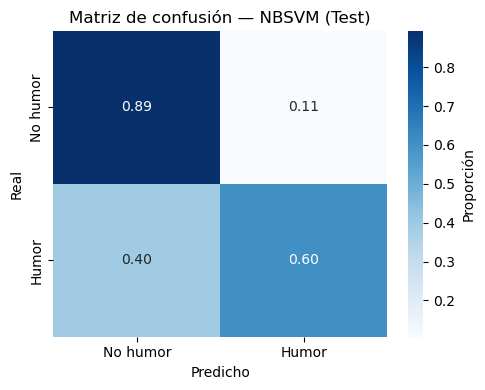

In [7]:
print('=== NBSVM ===')
display(get_classification_report_df(y_test, preds_nbsvm))

cm = get_confusion_matrix(y_test, preds_nbsvm, normalize='true', as_percentage=False)
_ = plot_confusion_matrix(cm, title='Matriz de confusión — NBSVM (Test)', is_percentage=False)

=== BETO baseline ===


,precision,recall,f1-score
No humor,0.870,0.892,0.881
Humor,0.821,0.788,0.804
macro avg,0.846,0.840,0.843


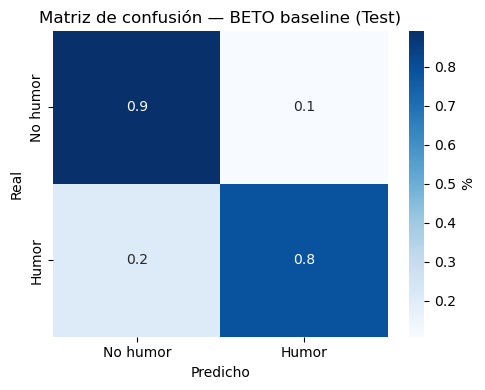

In [8]:
print('=== BETO baseline ===')
display(get_classification_report_df(y_test, preds_baseline))
cm = get_confusion_matrix(y_test, preds_baseline, normalize='true', as_percentage=False)
_ = plot_confusion_matrix(cm, title='Matriz de confusión — BETO baseline (Test)')

=== BETO + LoRA ===


,precision,recall,f1-score
No humor,0.895,0.872,0.884
Humor,0.805,0.837,0.821
macro avg,0.850,0.855,0.852


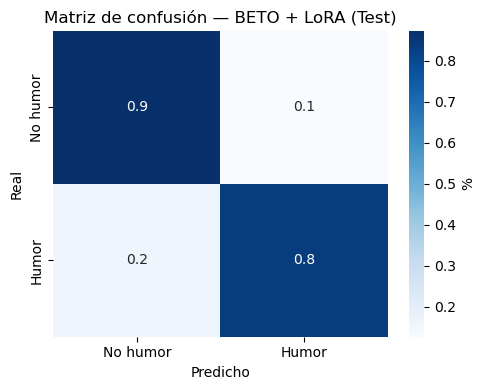

In [9]:
print('=== BETO + LoRA ===')
display(get_classification_report_df(y_test, preds_lora))
cm = get_confusion_matrix(y_test, preds_lora, normalize='true', as_percentage=False)
_ = plot_confusion_matrix(cm, title='Matriz de confusión — BETO + LoRA (Test)')

## 8. Guardar predicciones


In [ ]:
df_preds = df_test.copy()
df_preds['pred_nbsvm']    = preds_nbsvm
df_preds['prob_nbsvm']    = probs_nbsvm[:, 1]
df_preds['pred_baseline'] = preds_baseline
df_preds['prob_baseline'] = probs_baseline[:, 1]
df_preds['pred_lora']     = preds_lora
df_preds['prob_lora']     = probs_lora[:, 1]

df_preds.to_csv('../results/evaluation/test_predictions.csv', index=False)
